# `dpuct` — max-seeking tree search

Monte Carlo Tree Search propagates the **mean** return of a subtree. This is the correct statistic for
game play, where the agent must ultimately accept the expected outcome of a move. It is not the correct
statistic for discovery, where only the single best candidate produced by the search is retained and the
remainder are discarded. Under a mean backup, a branch containing one exceptional result and nine
failures ranks below a branch of nine mediocre results, and the search abandons the exceptional result.

`dpuct` modifies three components of PUCT:

| | classic PUCT | D-PUCT |
|---|---|---|
| **backup** | subtree mean | subtree **max**, `W_m(s)` |
| **prior** | softmax over *sibling* values | softmax over **archive-wide** ranks |
| **actions** | descend into a child | descend, **or sample one additional child** |

---
## Configuration reference

| parameter | symbol | description |
|---|---|---|
| `n_select` | n | number of targets returned per round |
| `k_children` | k | children generated for a leaf target; a virtual target always yields one |
| `c_puct` | c | exploration coefficient. At 0, selection is greedy with respect to `W_m` |
| `alpha` | α | 1.0 uses ranks only; 0.0 uses pairwise comparisons only |
| `lambda_virtual` | λ | optimism of the virtual child; 0 assigns no credit for variance |
| `tau` | τ | prior temperature; small values concentrate the prior, large values flatten it |
| `normalize_exploitation` | | rescales `W_m` to [0, 1] so that `c_puct` transfers across problems |
| `virtual_value_mode` | | `zero` (prior and bonus only) or `parent_mean` |
| `selection_mode` | | `node` (one target per node) or `action_descend` (MCTS-style descent) |
| `max_archive_size` | | limit on stored nodes; 0 removes the limit |

`c_puct` governs the explore/exploit balance and should be tuned first; the remaining parameters have
second-order effects.

## Setup

`numpy` is the only requirement. From the package directory:

```bash
pip install -e .          # or: pip install numpy
```

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # run from notebooks/ without installing

import numpy as np
from dpuct import DPUCT, DPUCTConfig, Tree, search

print('ready')

ready


---
## 1. The tree

A node holds a scalar `value`, interpreted as higher-is-better, and an arbitrary `payload` that the
library does not inspect. The payload may contain a board state, a program, or any other representation.

The tree constructed below has two branches: one containing a single high-value descendant among
failures, and one whose values are uniform.

In [2]:
tree = Tree()
root = tree.add_root(payload='start')

# Branch A: nine failures and one exceptional result.
branch_a = tree.add_child(root.id, value=0.1, payload='A')
for _ in range(9):
    tree.add_child(branch_a.id, value=0.0)
tree.add_child(branch_a.id, value=9.0, payload='the gem')

# Branch B: consistently mediocre.
branch_b = tree.add_child(root.id, value=1.0, payload='B')
for _ in range(10):
    tree.add_child(branch_b.id, value=1.0)

tree.recompute()      # refreshes m_s and W_m(s) bottom-up

mean_a = np.mean([c.value for c in tree.children(branch_a.id)])
mean_b = np.mean([c.value for c in tree.children(branch_b.id)])

print(f'branch A   mean of children = {mean_a:.2f}   W_m = {tree.get(branch_a.id).subtree_max:.2f}')
print(f'branch B   mean of children = {mean_b:.2f}   W_m = {tree.get(branch_b.id).subtree_max:.2f}')
print()
print('by mean  -> B looks better' if mean_b > mean_a else 'by mean  -> A looks better')
print('by W_m   -> A looks better' if tree.get(branch_a.id).subtree_max > tree.get(branch_b.id).subtree_max else 'by W_m   -> B looks better')

branch A   mean of children = 0.90   W_m = 9.00
branch B   mean of children = 1.00   W_m = 1.00

by mean  -> B looks better
by W_m   -> A looks better


A mean-backup search abandons branch A, which has already produced a value of 9.0, because its
average is reduced by the failures that such a search would in fact be free to discard.

---
## 2. The global prior

Classic PUCT derives its prior from sibling values. A node consequently appears strong merely by
comparison with weak siblings.

D-PUCT instead ranks each node against the entire archive and standardizes the result. Ranks are used
rather than raw values, which makes the signal invariant to the scale of the reward and to outliers.

In [3]:
policy = DPUCT(DPUCTConfig(alpha=1.0))   # alpha=1.0 -> rank signal only
logits = policy.global_logits(tree)

print(f'L_D(branch A) = {logits[branch_a.id]:+.3f}')
print(f'L_D(branch B) = {logits[branch_b.id]:+.3f}')
print()

L_D(branch A) = +1.754
L_D(branch B) = +0.614



---
## 3. The virtual child

Standard MCTS answers only the question of which existing child to descend into. It provides no
principled mechanism for asking whether an additional child should be generated at a given parent.

D-PUCT introduces this as an explicit action, assigned the logit

$$L_p(\hat{s}) = \mu_L(p) + \lambda\,\sigma_L(p)$$

that is, the mean logit of the existing children plus λ standard deviations.

The standard-deviation term carries the essential behaviour. High variance among a parent's children
indicates that sampling from that parent yields heterogeneous outcomes, and when only the best result is
retained, heterogeneity constitutes unrealized upside. A parent that produced {0.0, 0.1, 9.0} is
therefore a more promising candidate for an additional sample than one that produced {1.0, 1.0, 1.0},
notwithstanding the higher mean of the latter.

In [4]:
def virtual_logit(child_values, lam=1.0):
    t = Tree()
    r = t.add_root()
    for v in child_values:
        t.add_child(r.id, value=v)
    t.recompute()
    p = DPUCT(DPUCTConfig(lambda_virtual=lam, alpha=1.0))
    pp = p.parent_priors(t, p.global_logits(t))[r.id]
    return pp.mu, pp.sigma, pp.logits['__virtual__']

for label, values in [('consistent  {1,1,1,1}', [1, 1, 1, 1]),
                      ('varied      {0,0,1,9}', [0, 0, 1, 9])]:
    mu, sigma, virt = virtual_logit(values)
    print(f'{label}:  mu={mu:+.3f}  sigma={sigma:.3f}  ->  L(virtual)={virt:+.3f}')

print()
print('lambda controls how much that spread is worth:')
for lam in (0.0, 0.5, 1.0, 2.0):
    _, _, virt = virtual_logit([0, 0, 1, 9], lam=lam)
    print(f'  lambda={lam:<4} -> L(virtual) = {virt:+.3f}')

consistent  {1,1,1,1}:  mu=+0.000  sigma=0.000  ->  L(virtual)=+0.000
varied      {0,0,1,9}:  mu=+0.000  sigma=1.000  ->  L(virtual)=+1.000

lambda controls how much that spread is worth:
  lambda=0.0  -> L(virtual) = +0.000
  lambda=0.5  -> L(virtual) = +0.500
  lambda=1.0  -> L(virtual) = +1.000
  lambda=2.0  -> L(virtual) = +2.000


Setting `lambda_virtual = 0` prices an unseen sibling at the mean logit of its siblings, with no
optimism. Increasing it causes the search to widen at parents whose outputs have been heterogeneous.

---
## 4. Selection

`select()` returns targets, which identify where further work is to be performed. Two kinds occur:

- `kind='leaf'`: expand the node into `num_children` children (deepening)
- `kind='virtual'`: add exactly one child to the node (widening)

Since a leaf target yields `k` children and a virtual target yields one, a round of `n` targets produces
between `n` and `n·k` children.

`explain()` reports the score decomposition for each candidate target, which is the most direct way to
determine why a particular target was chosen.

In [5]:
policy = DPUCT(DPUCTConfig(n_select=4, k_children=6, c_puct=1.0, alpha=1.0))
print(policy.explain(tree, limit=8))

print()
targets = policy.select(tree)
for t in targets:
    print(t)
print()
print(f'this round would produce {sum(t.num_children for t in targets)} children',
      f'(bounds: {policy.config.n_select} .. {policy.config.n_select * policy.config.k_children})')

kind     node         x     score         V   prior     bonus
------------------------------------------------------------
virtual  f3b897d0     1    2.0674    0.0000   0.431    2.0674
leaf     96c41f95     6    1.9905    1.0000   0.597    0.9905
virtual  e31df34f     1    0.3489    0.0000   0.105    0.3489
virtual  c297993d     1    0.3015    0.0000   0.091    0.3015
leaf     e4ad1d10     6    0.2619    0.1111   0.091    0.1508
leaf     217d2990     6    0.2619    0.1111   0.091    0.1508
leaf     227c71d6     6    0.2619    0.1111   0.091    0.1508
leaf     ca6e9be2     6    0.2619    0.1111   0.091    0.1508

Target(virtual, node=f3b897d0, x1, score=2.0674 = V 0.0000 + bonus 2.0674)
Target(leaf, node=96c41f95, x6, score=1.9905 = V 1.0000 + bonus 0.9905)
Target(virtual, node=e31df34f, x1, score=0.3489 = V 0.0000 + bonus 0.3489)
Target(virtual, node=c297993d, x1, score=0.3015 = V 0.0000 + bonus 0.3015)

this round would produce 9 children (bounds: 4 .. 24)


### The exploration coefficient

At `c_puct = 0`, selection is greedy with respect to `W_m`. Increasing the coefficient transfers weight
to the prior and visit-count bonus.

In [6]:
for c in (0.0, 0.5, 2.0):
    p = DPUCT(DPUCTConfig(n_select=3, c_puct=c, alpha=1.0))
    picks = p.select(tree)
    kinds = ', '.join(f"{t.kind}({t.score:.2f})" for t in picks)
    print(f'c_puct={c:<4} -> {kinds}')

c_puct=0.0  -> leaf(1.00), leaf(0.11), leaf(0.11)
c_puct=0.5  -> leaf(1.50), virtual(1.03), leaf(0.19)
c_puct=2.0  -> virtual(4.13), leaf(2.98), virtual(0.70)


---
## 5. Driving a search

Where a search loop already exists, `select()` may be used directly as its selection step and the
remainder of this section may be omitted.

Otherwise, supplying an `expand` function allows `search()` to drive the procedure:

```python
expand(node, num_children) -> [(value, payload), ...]
```

The example below maximizes the negated Rastrigin function, which contains a large number of local
optima and therefore penalizes a search that commits to its starting basin. Each node holds a point;
expansion perturbs that point, with the step size decreasing as depth increases.

In [7]:
import math, random

def rastrigin(p):
    return -sum(x*x - 10*math.cos(2*math.pi*x) + 10 for x in p)

rng = random.Random(0)
SPAN = 5.12

def expand(node, num_children):
    base = node.payload if node.payload is not None else [0.0, 0.0]
    step = SPAN / (2 ** min(node.depth, 8))      # coarse near the root, fine below
    out = []
    for _ in range(num_children):
        child = [max(-SPAN, min(SPAN, x + rng.gauss(0, step))) for x in base]
        out.append((rastrigin(child), child))
    return out

start = [rng.uniform(-SPAN, SPAN) for _ in range(2)]
result = search(expand, rounds=25,
                config=DPUCTConfig(n_select=4, k_children=6, c_puct=0.7,
                                   alpha=1.0, max_archive_size=2000),
                root_payload=start)

print(f'started at f = {rastrigin(start):9.4f}  {np.round(start, 3)}')
print(f'found      f = {result.best_value:9.4f}  {np.round(result.best_payload, 3)}')
print(f'optimum    f =    0.0000  [0. 0.]')
print(result.tree.summary())

started at f =  -55.5775  [3.527 2.641]
found      f =   -0.0089  [ 0.004 -0.005]
optimum    f =    0.0000  [0. 0.]
{'nodes': 383, 'roots': 1, 'leaves': 326, 'max_depth': 11, 'best_value': -0.008935807852688882}


round   0  targets=  1 (1L/0V) children=   6 |D|=    7 best=-33.802243
round   5  targets=  4 (3L/1V) children=  19 |D|=  107 best=-0.808562
round  10  targets=  4 (2L/2V) children=  14 |D|=  187 best=-0.086039
round  15  targets=  4 (1L/3V) children=   9 |D|=  252 best=-0.021718
round  20  targets=  4 (2L/2V) children=  14 |D|=  327 best=-0.009011


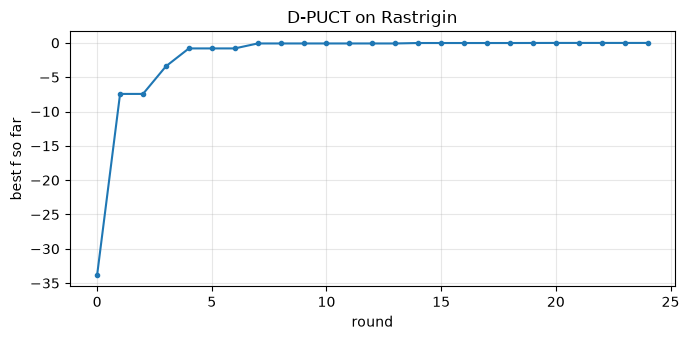

In [8]:
# The best-so-far curve is monotone by construction: you keep the best.
for s in result.history[::5]:
    print(s)

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 3.5))
    plt.plot(result.curve(), marker='o', ms=3)
    plt.xlabel('round'); plt.ylabel('best f so far')
    plt.title('D-PUCT on Rastrigin'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
except ImportError:
    print('\n(install matplotlib to see the curve)')

---
## 6. Drawing the tree

Rendering the tree is the most direct means of assessing whether the exploration coefficient is
producing the intended behaviour. Four renderers are provided, in increasing order of dependency:

| | requires | suited to |
|---|---|---|
| `tree.render()` / `render_text` | nothing | terminals, logs, quick inspection |
| `to_mermaid` | nothing | GitHub markdown and many notebook viewers |
| `to_dot` | nothing (Graphviz to rasterize) | publication figures |
| `tree.draw()` | matplotlib | trees of more than a few dozen nodes |

Each node displays the three quantities from which selection is computed: `Q`, the node's own value;
`W`, the subtree maximum; and `m`, the subtree size. Divergence between `W` and `Q` along a branch
indicates that the max backup is retaining a descendant which a mean backup would have suppressed.

Passing the result of `select()` as `targets` marks the nodes chosen in the current round.

In [9]:
from dpuct import render_text, to_mermaid, to_dot, path_to_best

# Rebuild the tree from section 1.
demo = Tree()
root_d = demo.add_root(payload='start')
branch = demo.add_child(root_d.id, value=0.1, payload='A')
for _ in range(4):
    demo.add_child(branch.id, value=0.0)
demo.add_child(branch.id, value=9.0, payload='gem')
flat = demo.add_child(root_d.id, value=1.0, payload='B')
demo.add_child(flat.id, value=1.1)
demo.recompute()

picked = DPUCT(DPUCTConfig(n_select=3, k_children=4, c_puct=1.0, alpha=1.0)).select(demo)

demo.show(targets=picked)
print()
print('trimmed to the two strongest children per node:')
print(demo.render(max_children=2))

> Q=0 W=9 m=9   <- selected (virtual)
|-- o Q=0.1 W=9 m=6
|   |-- o Q=0 W=0 m=1
|   |-- o Q=0 W=0 m=1
|   |-- o Q=0 W=0 m=1
|   |-- o Q=0 W=0 m=1
|   `-- > Q=9 W=9 m=1   <- selected (leaf)
`-- > Q=1 W=1.1 m=2   <- selected (virtual)
    `-- o Q=1.1 W=1.1 m=1
@ root   * best   > selected   o node

trimmed to the two strongest children per node:
@ Q=0 W=9 m=9
|-- o Q=0.1 W=9 m=6
|   |-- * Q=9 W=9 m=1
|   |-- o Q=0 W=0 m=1
|   `-- ... 3 weaker sibling(s)
`-- o Q=1 W=1.1 m=2
    `-- o Q=1.1 W=1.1 m=1
@ root   * best   > selected   o node


On branch A, `Q=0.1 W=9` records that the branch's own value is 0.1 while the best result beneath it is
9.0. A mean backup would report 0.9 for the same branch.

`max_depth` and `max_children` restrict the displayed subset. Trimming retains the highest-valued
children rather than the first ones, so the exceptional descendant survives even at `max_children=1`,
and every omission is reported rather than silently applied.

### Mermaid and Graphviz

Both renderers return source text rather than an image. Mermaid output may be embedded directly in
GitHub markdown; Graphviz output is rasterized with `dot -Tpng tree.dot -o tree.png`.

In [10]:
# Mermaid and Graphviz are returned as plain strings, for embedding or rasterizing.
print(to_mermaid(demo, max_depth=2))
print()
print(to_dot(demo, max_depth=2, targets=picked)[:260], '...')

graph TD
  276b53["Q=0<br/>W=9"]
  f61afc["Q=0.1<br/>W=9"]
  276b53 --> f61afc
  2e9581["Q=0<br/>W=0"]
  f61afc --> 2e9581
  e6ea56["Q=0<br/>W=0"]
  f61afc --> e6ea56
  587d96["Q=0<br/>W=0"]
  f61afc --> 587d96
  3285f5["Q=0<br/>W=0"]
  f61afc --> 3285f5
  825f01["Q=9<br/>W=9"]
  f61afc --> 825f01
  7b7af1["Q=1<br/>W=1.1"]
  276b53 --> 7b7af1
  353593["Q=1.1<br/>W=1.1"]
  7b7af1 --> 353593
  style 276b53 fill:#e8e8e8,stroke:#666
  style 825f01 fill:#c8e6c9,stroke:#2e7d32,stroke-width:3px

digraph dpuct {
  rankdir=TB;
  node [shape=box, style="rounded,filled", fontname="monospace", fontsize=10, fillcolor="#ffffff"];
  "276b53" [label="Q=0\nW=9\nm=9", fillcolor="#e8e8e8"];
  "f61afc" [label="Q=0.1\nW=9\nm=6"];
  "276b53" -> "f61afc";
  "2e9581"  ...


### Matplotlib

Node colour encodes the node's value and node size increases with subtree size. The best node is
circled in red and selected targets are enclosed in orange squares.

In the lower panel the search fans out near the root and subsequently drives a single lineage deep, as
`W_m` sustains the attractiveness of that branch. A tree that forms a single deep path with no fan
indicates that `c_puct` is too low; one that remains broad without descending indicates it is too high.

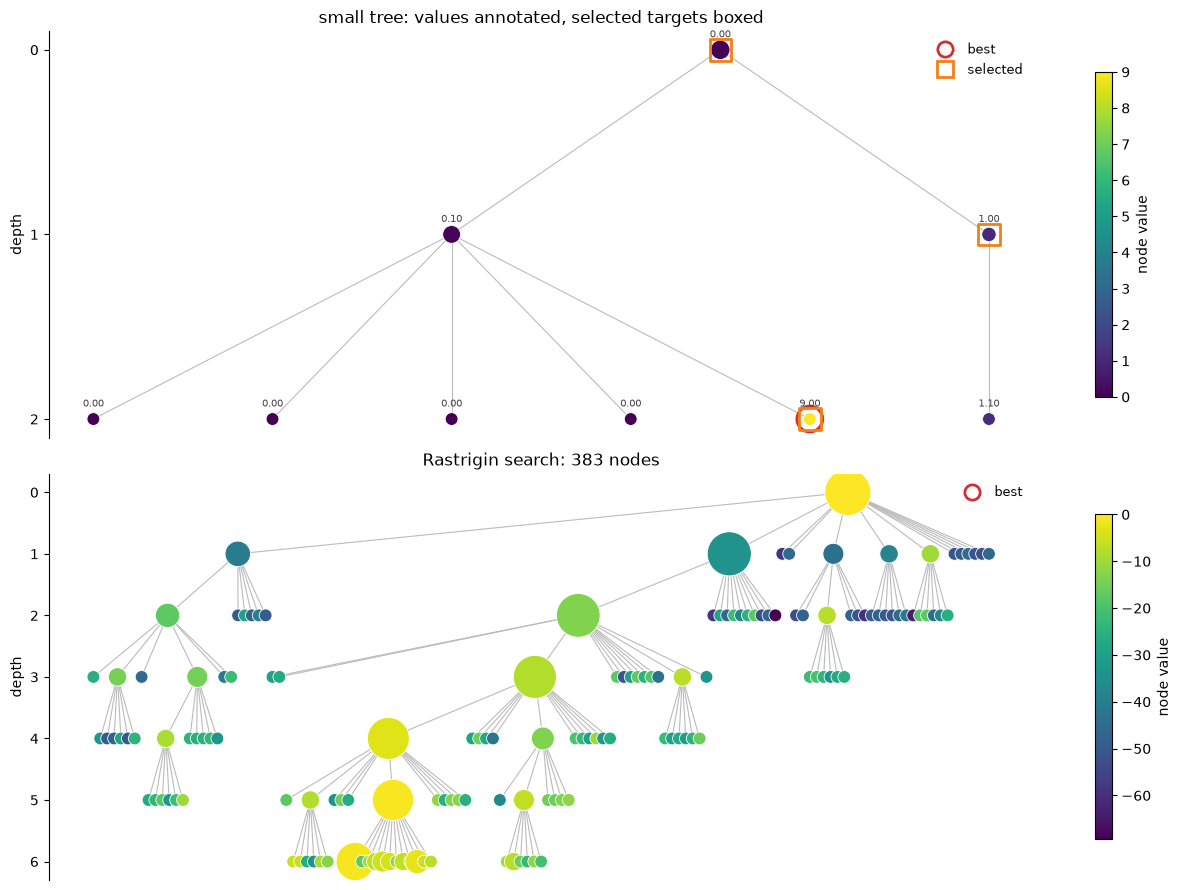

In [11]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 1, figsize=(13, 9))
    demo.draw(ax=axes[0], targets=picked, annotate=True,
              title='small tree: values annotated, selected targets boxed')
    result.tree.draw(ax=axes[1], max_depth=6,
                     title=f'Rastrigin search: {len(result.tree)} nodes')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib is not installed; the remaining renderers require nothing.')

---
## 7. Integration with an existing MCTS

The policy holds no state associated with the tree, so integration is confined to the selection step.

In [12]:
# Sketch: replace your selection step, keep everything else.

my_tree = Tree()
root = my_tree.add_root(payload='initial state')
policy = DPUCT(DPUCTConfig(n_select=2, k_children=3, c_puct=1.0, alpha=1.0))

for round_index in range(3):
    my_tree.recompute()                       # 1. refresh W_m and m_s
    for target in policy.select(my_tree):     # 2. pick where to work
        node = my_tree.get(target.node_id)
        # 3. YOUR code: roll out / call a model / run a simulator
        for i in range(target.num_children):
            value = rng.random()              # <- your evaluation
            my_tree.add_child(node.id, value=value, payload=f'r{round_index}c{i}')

my_tree.recompute()
print(my_tree.summary())
print('best payload:', my_tree.best().payload)

{'nodes': 14, 'roots': 1, 'leaves': 10, 'max_depth': 3, 'best_value': 0.9344608884461488}
best payload: r2c2


Three requirements govern the integration:

1. `tree.recompute()` must be called before `select()`; the statistics are not maintained incrementally.
2. `value` is always interpreted as higher-is-better. For a minimization objective, store its negation.
3. `target.num_children` should be respected: `k` for a leaf target and exactly one for a virtual
   target. Returning fewer children is permitted.